To demonstrate Type I and Type II errors, we can use a Monte Carlo simulation. This allows us to observe these errors in action by repeatedly testing a hypothesis where we know the absolute truth.

### **The Simulation Scenario: Quality Control**

Imagine we are testing a process that should produce components with a mean weight of 100g.
- **Null Hypothesis ($H_0$):** Mean = 100g (Process is working correctly).
- **Alternative Hypothesis ($H_a$):** Mean $\neq$ 100g (Process is flawed).
- **Significance Level ($\alpha$):** 0.05.

In [46]:
import pandas as pd
import numpy as np
from scipy import stats
import itertools
import math
import matplotlib.pyplot as plt

In [2]:
def run_simulation(n_simulations=10000, true_mean=100, observed_mean=100): # It repeats the experiment 10,000 times to get a statistically significant average error rate.
    type_i_errors = 0
    type_ii_errors = 0
    
    for _ in range(n_simulations):
        # Generate a sample of 30 components
        sample = np.random.normal(loc=observed_mean, scale=10, size=30)
        
        # Perform a one-sample t-test
        t_stat, p_value = stats.ttest_1samp(sample, 100) # performs a one-sample T-test. It asks: "Is the mean of my 30 samples statistically different from the benchmark of 100?"
        
        # Type I Error: Reject H0 (p < 0.05) when H0 is actually True (true_mean == 100)
        if true_mean == 100 and p_value < 0.05: 
            type_i_errors += 1
            
        # Type II Error: Fail to reject H0 (p >= 0.05) when H0 is False (true_mean != 100)
        # the test incorrectly concludes there is no difference even though the mean actually shifted to 105.
        elif true_mean != 100 and p_value >= 0.05: 
            type_ii_errors += 1
            
    return type_i_errors / n_simulations, type_ii_errors / n_simulations

In [3]:
# Scenario A: The process is perfect (True Mean = 100)
type_i_rate, _ = run_simulation(true_mean=100, observed_mean=100)

# Scenario B: The process is flawed (True Mean = 105)
# This allows the code to calculate how often the test fails to detect the shift to 105. This is your Type II error rate.
_, type_ii_rate = run_simulation(true_mean=105, observed_mean=105) 

print(f"Observed Type I Error Rate: {type_i_rate:.4f} (Should be near 0.05)")
print(f"Observed Type II Error Rate: {type_ii_rate:.4f} (Probability of missing the defect)")

Observed Type I Error Rate: 0.0493 (Should be near 0.05)
Observed Type II Error Rate: 0.2541 (Probability of missing the defect)


### Hypothesis Testing and Type I error

In [44]:
# 1. Generate a dataframe with the height of 22 random people (in cm)
np.random.seed(42)
heights = np.random.normal(loc=170, scale=10, size=22)
df = pd.DataFrame({'Height': heights})
df

,Height
0,174.967142
1,168.617357
2,176.476885
3,185.230299
4,167.658466
5,167.658630
6,185.792128
7,177.674347
8,165.305256
9,175.425600


In [45]:
# 2. Calculate the population mean
population_mean = df['Height'].mean()
print(f"Population Mean: {population_mean:.2f}")

Population Mean: 169.01


In [47]:
# 3. Use combinatorics to calculate 22 choose 17
n = 22
k = 17
num_combinations = math.comb(n, k)
print(f"Number of possible samples (22 choose 17): {num_combinations}")

Number of possible samples (22 choose 17): 26334


In [48]:
# 4. Calculate the sample mean of each possible sample
# Generate all combinations of indices
indices = range(n)
comb_indices = itertools.combinations(indices, k)

# Calculate means
sample_means = []
for combo in comb_indices:
    sample = df.iloc[list(combo)]
    sample_means.append(sample['Height'].mean())

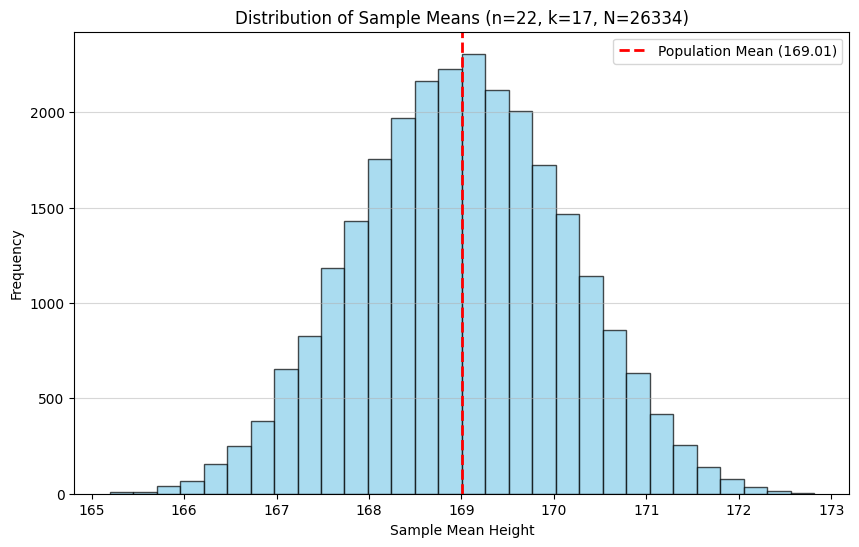

In [49]:
# 5. Plot the distribution of sample means
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=2, label=f'Population Mean ({population_mean:.2f})')
plt.title(f'Distribution of Sample Means (n=22, k=17, N={num_combinations})')
plt.xlabel('Sample Mean Height')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

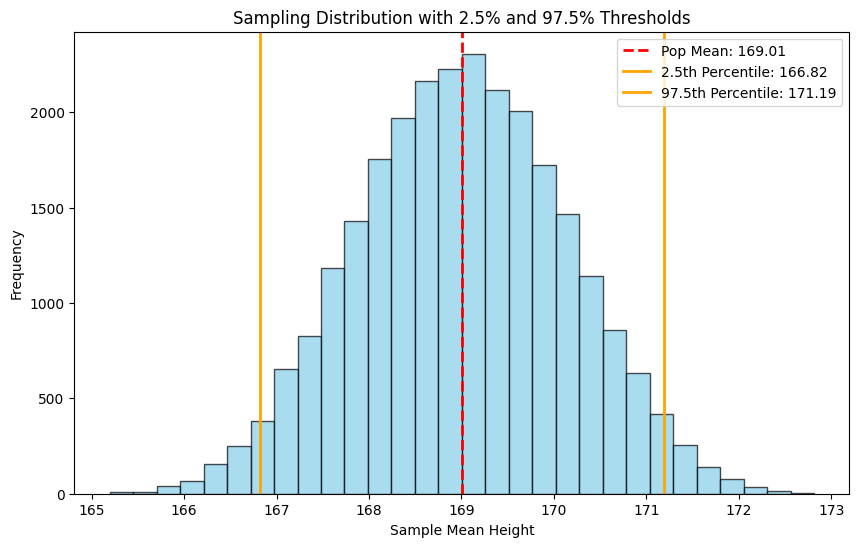

In [51]:
# Calculate the 2.5th and 97.5th percentiles (critical values for alpha = 0.05 two-sided)
lower_bound = np.percentile(sample_means, 2.5)
upper_bound = np.percentile(sample_means, 97.5)

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Population mean line
plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=2, label=f'Pop Mean: {population_mean:.2f}')

# Significance threshold lines
plt.axvline(lower_bound, color='orange', linestyle='solid', linewidth=2, label=f'2.5th Percentile: {lower_bound:.2f}')
plt.axvline(upper_bound, color='orange', linestyle='solid', linewidth=2, label=f'97.5th Percentile: {upper_bound:.2f}')

plt.title(f'Sampling Distribution with 2.5% and 97.5% Thresholds')
plt.xlabel('Sample Mean Height')
plt.ylabel('Frequency')
plt.legend()
plt.show()

H0: sample mean = population mean

H1: sample mean $\neq$ population mean

In [50]:
1/26334
# O.0000379
# 0.00379%  Type I error

3.79737221842485e-05

In [57]:
# 'df' is the original DataFrame of 22 people
# 'population_mean' is the mean of all 22
# 'sample' is one of your 17-person selections

# Perform the two-sided T-test
t_stat, p_value = stats.ttest_1samp(sample['Height'], population_mean)

# Determine rejection at alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print(f"Reject the Null Hypothesis (p={p_value:.4f})")
else:
    print(f"Fail to reject the Null Hypothesis (p={p_value:.4f})")

Fail to reject the Null Hypothesis (p=0.5087)


In [58]:
sample['Height']

5     167.658630
6     185.792128
7     177.674347
8     165.305256
9     175.425600
10    165.365823
11    165.342702
12    172.419623
13    150.867198
14    152.750822
15    164.377125
16    159.871689
17    173.142473
18    160.919759
19    155.876963
20    184.656488
21    167.742237
Name: Height, dtype: float64